# 05 — M3: Can Audio Predict the Compartmental Contribution (%RC)?

**Pipeline stage:** Milestone&nbsp;3 — moving from *correlation* (M2) to *prediction*. The central
question: can frame-level audio features predict the rib-cage volume contribution `pct_rc`, and is
that mapping consistent within a subject but not across the population?

**Scripts reproduced**
| Script | Role |
|--------|------|
| `scripts/analyze_compartmental_regression.py` | per-subject vs pooled vs stratified Ridge regression, binning ANOVA |
| `scripts/diagnose_compartmental_signal.py` | variance decomposition, within-task tracking, segment-level reframing |

> **Plot types:** per-subject R² histogram, coefficient-importance bar, R² comparison bar,
> binning feature-profile line plot, variance-decomposition histogram, framing-comparison bar.
>
> ⚠️ Requires scikit-learn. This notebook fits many cross-validated models over the full corpus,
> so it takes a couple of minutes.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

import analyze_compartmental_regression as cr
import diagnose_compartmental_signal as diag
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
META_PATH  = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
TARGET = "pct_rc"

## 1. Build the frame-level dataset
`cr.build_frame_dataset` loads every recording, keeps voiced frames, and attaches the audio
predictors (`f0`, `energy`, `spectral_centroid`, `mfcc_0..12`) + the target + demographics.

In [2]:

metadata = cr.load_metadata(META_PATH)
frames, features = cr.build_frame_dataset(PAIRED_DIR, metadata, TARGET)
print(f"{len(frames):,} voiced frames | {frames['subject_id'].nunique()} subjects | {len(features)} predictors")
print("predictors:", features)

2026-06-10 19:24:30,906 - analyze_compartmental_regression - INFO - Found 546 paired HDF5 files
2026-06-10 19:24:37,197 - analyze_compartmental_regression - INFO - Frame dataset: 198630 voiced frames, 38 subjects, 16 features


198,630 voiced frames | 38 subjects | 16 predictors
predictors: ['f0', 'energy', 'spectral_centroid', 'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12']


## 2. Per-subject regression — the make-or-break test
For each subject, `RidgeCV(audio → %RC)` with **leave-one-task-out** cross-validation. If most
subjects show positive R², the mapping exists at the subject level.

2026-06-10 19:24:42,499 - analyze_compartmental_regression - INFO - Per-subject regression: 37 subjects analyzed, median CV R^2 = -0.462


subjects analysed: 37
median CV R²: -0.462 | subjects with R²>0: 3%


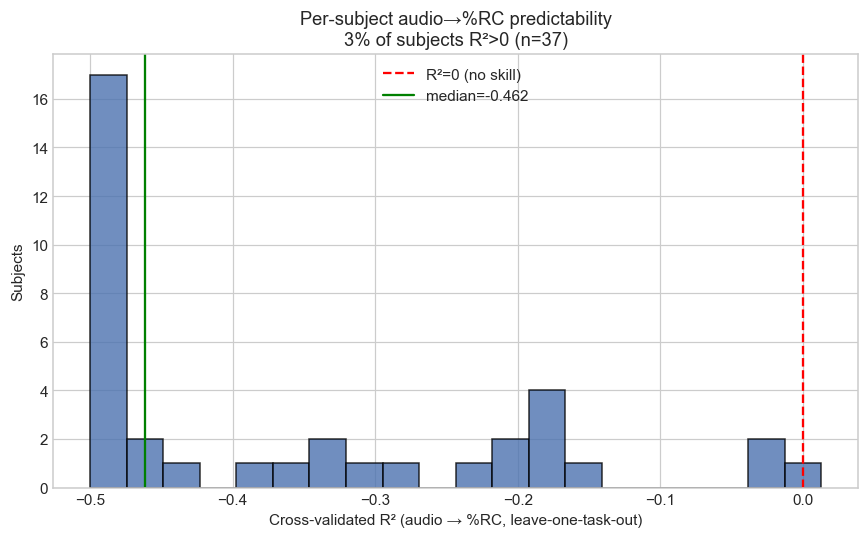

In [3]:

per_subj = cr.per_subject_regression(frames, features, TARGET)
print(f"subjects analysed: {len(per_subj)}")
print(f"median CV R²: {per_subj['r2_cv'].median():.3f} | subjects with R²>0: {(per_subj['r2_cv']>0).mean():.0%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(per_subj['r2_cv'].clip(lower=-0.5), bins=20, color='#4c72b0', alpha=0.8, edgecolor='black')
ax.axvline(0, color='red', ls='--', label='R²=0 (no skill)')
ax.axvline(per_subj['r2_cv'].median(), color='green', label=f"median={per_subj['r2_cv'].median():.3f}")
ax.set_xlabel('Cross-validated R² (audio → %RC, leave-one-task-out)'); ax.set_ylabel('Subjects')
ax.set_title(f"Per-subject audio→%RC predictability\n{(per_subj['r2_cv']>0).mean():.0%} of subjects R²>0 (n={len(per_subj)})")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Which audio features carry %RC information?
Mean |standardized Ridge coefficient| across subjects; green bars are sign-consistent across
≥70% of subjects.

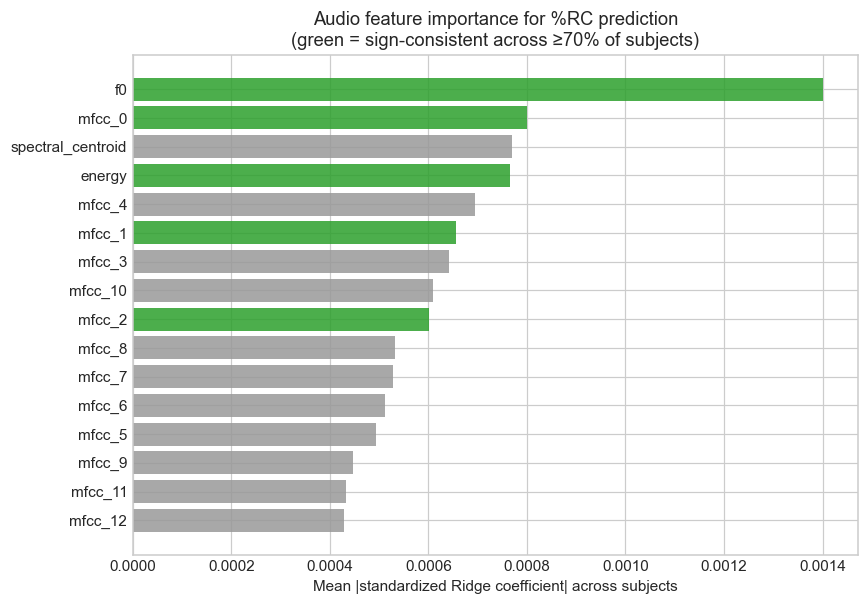

In [4]:

coef_cols = [f'coef_{f}' for f in features]
mean_abs = per_subj[coef_cols].abs().mean().sort_values(ascending=True)
labels = [c.replace('coef_', '') for c in mean_abs.index]
sign_cons = {}
for f in features:
    c = per_subj[f'coef_{f}']; modal = np.sign(c.median())
    sign_cons[f] = (np.sign(c) == modal).mean() if modal != 0 else 0.5
colors = ['#2ca02c' if sign_cons[l] >= 0.7 else '#999999' for l in labels]

fig, ax = plt.subplots(figsize=(8, max(4, 0.35*len(features))))
ax.barh(range(len(mean_abs)), mean_abs.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(mean_abs))); ax.set_yticklabels(labels)
ax.set_xlabel('Mean |standardized Ridge coefficient| across subjects')
ax.set_title('Audio feature importance for %RC prediction\n(green = sign-consistent across ≥70% of subjects)')
plt.tight_layout(); plt.show()

## 4. Per-subject vs pooled vs stratified
The negative control: one pooled model (leave-one-subject-out) should do *worse* than per-subject
models if the mapping is subject-specific. A large positive gap is the evidence.

pooled CV R²=-0.095 | per-subject median=-0.462 | gap=-0.367


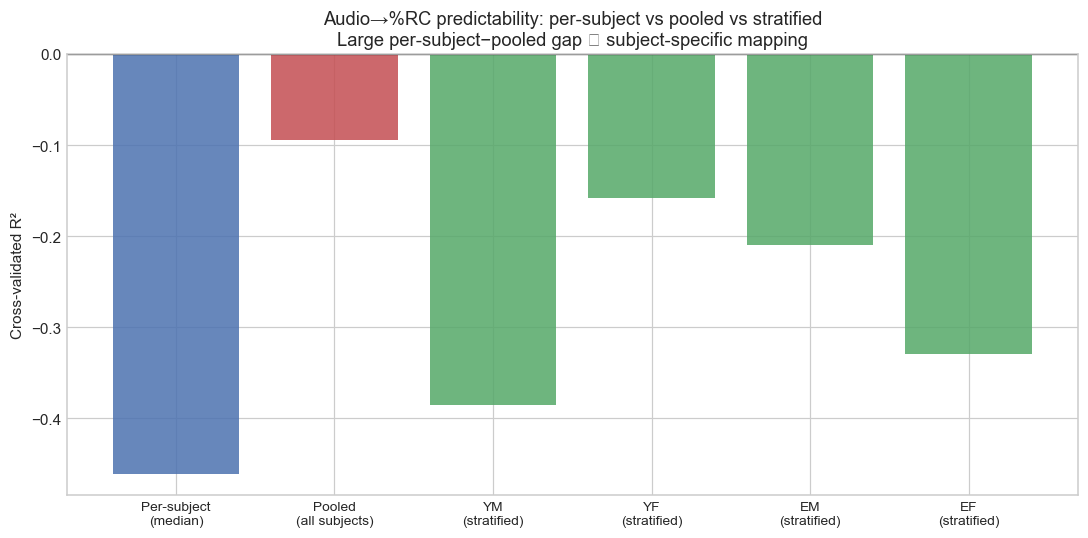

In [5]:

pooled_r2, _ = cr.grouped_regression_r2(frames, features, TARGET)
strat_df = cr.stratified_regression(frames, features, TARGET)
print(f"pooled CV R²={pooled_r2:+.3f} | per-subject median={per_subj['r2_cv'].median():+.3f} | "
      f"gap={per_subj['r2_cv'].median()-pooled_r2:+.3f}")

labels = ['Per-subject\n(median)', 'Pooled\n(all subjects)'] + [f"{r.stratum}\n(stratified)" for r in strat_df.itertuples()]
values = [per_subj['r2_cv'].median(), pooled_r2] + list(strat_df['r2_cv'])
colors = ['#4c72b0', '#c44e52'] + ['#55a868']*len(strat_df)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(values)), values, color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(values))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Cross-validated R²')
ax.set_title('Audio→%RC predictability: per-subject vs pooled vs stratified\nLarge per-subject−pooled gap ⇒ subject-specific mapping')
plt.tight_layout(); plt.show()

## 5. Binning EDA (model-free)
Bin %RC into quantile bands and ask, per feature, whether the feature mean differs across bands
(one-way ANOVA, η² effect size). Then plot the standardized feature profiles of the top features.

,feature,anova_F,anova_p,eta_squared
0,spectral_centroid,541.0628,0.0,0.0108
1,f0,251.2928,0.0,0.0050
2,mfcc_0,122.9271,0.0,0.0025
3,mfcc_9,67.8281,0.0,0.0014
4,mfcc_12,58.8833,0.0,0.0012
5,mfcc_6,44.7147,0.0,0.0009
6,mfcc_7,44.2732,0.0,0.0009
7,mfcc_10,36.2280,0.0,0.0007


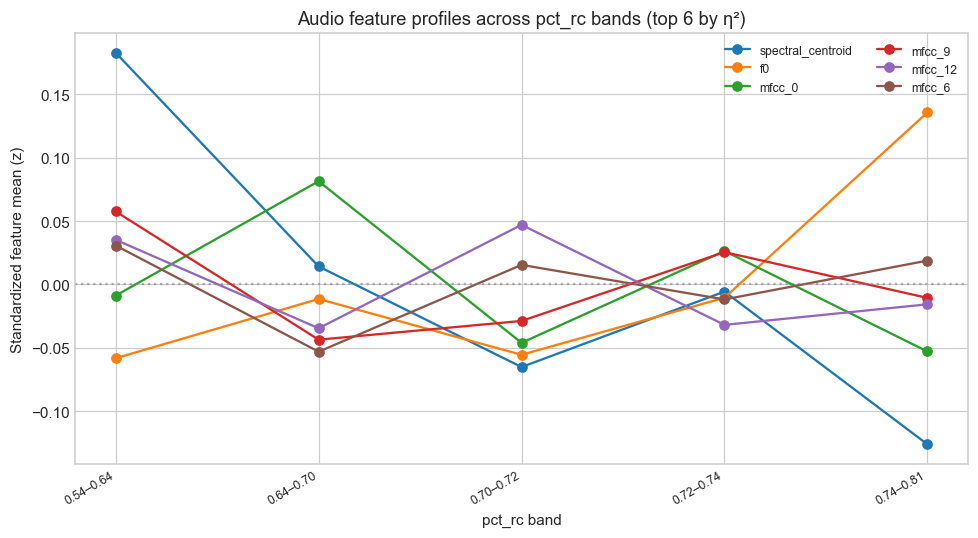

In [6]:

anova = cr.binning_analysis(frames, features, TARGET)
display(anova.head(8).round(4).reset_index(drop=True))

n_bins = 5
fr = frames.copy(); fr['_band'] = pd.qcut(fr[TARGET], q=n_bins, duplicates='drop')
bands = sorted(fr['_band'].dropna().unique(), key=lambda b: b.left)
band_labels = [f'{b.left:.2f}–{b.right:.2f}' for b in bands]
fig, ax = plt.subplots(figsize=(9, 5))
for feat in anova.head(6)['feature']:
    means = np.array([fr.loc[fr['_band']==b, feat].mean() for b in bands])
    sd = fr[feat].std(); zz = (means - fr[feat].mean())/sd if sd>0 else means
    ax.plot(range(len(bands)), zz, marker='o', label=feat)
ax.axhline(0, color='gray', ls=':', alpha=0.6)
ax.set_xticks(range(len(bands))); ax.set_xticklabels(band_labels, rotation=30, ha='right', fontsize=8)
ax.set_xlabel(f'{TARGET} band'); ax.set_ylabel('Standardized feature mean (z)')
ax.set_title(f'Audio feature profiles across {TARGET} bands (top 6 by η²)'); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 6. Diagnostic — why does cross-task prediction fail?
`diagnose_compartmental_signal` decomposes %RC variance into within-recording vs between-recording.
If %RC is mostly *between* tasks, frame-level within-task prediction is ill-posed.

median within-task fraction of %RC variance: 0.39


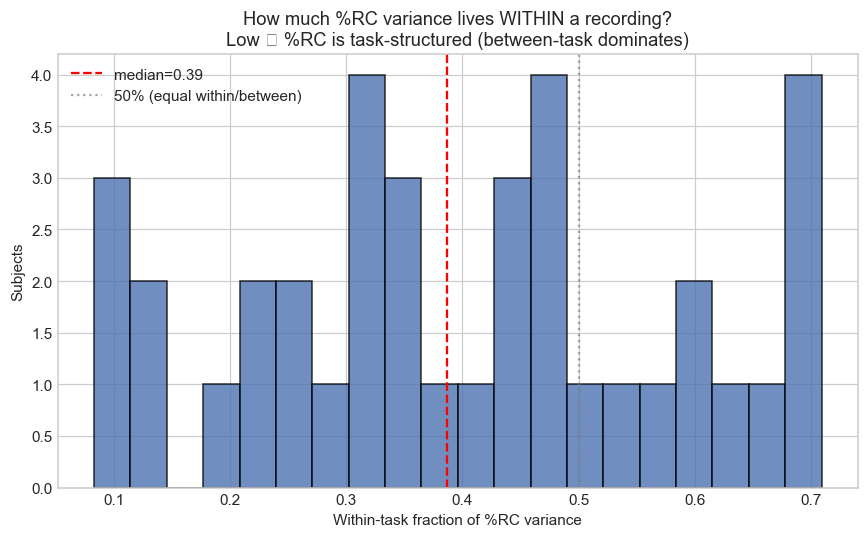

In [7]:

# reuse the frames we already loaded; add the frame ordering the diagnostic needs
frames_d = frames.copy()
frames_d['frame_order'] = frames_d.groupby(['subject_id', 'task']).cumcount()

decomp = diag.variance_decomposition(frames_d, TARGET)
print(f"median within-task fraction of %RC variance: {decomp['within_fraction'].median():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(decomp['within_fraction'], bins=20, color='#4c72b0', alpha=0.8, edgecolor='black')
ax.axvline(decomp['within_fraction'].median(), color='red', ls='--',
           label=f"median={decomp['within_fraction'].median():.2f}")
ax.axvline(0.5, color='gray', ls=':', alpha=0.7, label='50% (equal within/between)')
ax.set_xlabel('Within-task fraction of %RC variance'); ax.set_ylabel('Subjects')
ax.set_title('How much %RC variance lives WITHIN a recording?\nLow ⇒ %RC is task-structured (between-task dominates)')
ax.legend(); plt.tight_layout(); plt.show()

### 6b. Framing comparison
Three ways to pose the prediction problem. Within-task (blocked CV) and segment-level (one row per
recording) are better posed than the failed cross-task framing.

cross-task(frame)=-0.462 | within-task(blocked)=-0.478 | segment-level=-0.050


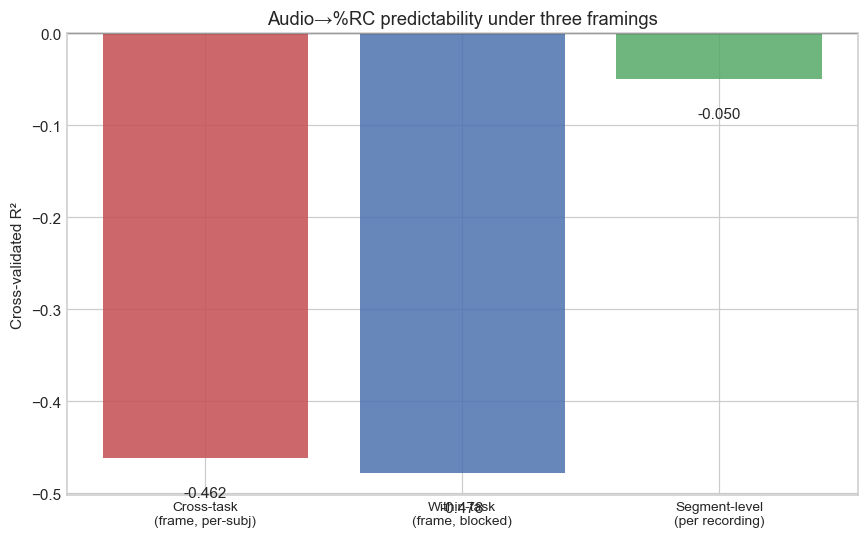

In [8]:

within_df = diag.within_task_r2(frames_d, features, TARGET)
within_med = within_df['r2_within'].dropna().median()
segment_r2, n_seg, _ = diag.segment_level_r2(frames_d, features, TARGET)
cross_task_r2 = per_subj['r2_cv'].median()
print(f"cross-task(frame)={cross_task_r2:+.3f} | within-task(blocked)={within_med:+.3f} | segment-level={segment_r2:+.3f}")

labels = ['Cross-task\n(frame, per-subj)', 'Within-task\n(frame, blocked)', 'Segment-level\n(per recording)']
values = [cross_task_r2, within_med, segment_r2]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(3), values, color=['#c44e52', '#4c72b0', '#55a868'], alpha=0.85)
ax.axhline(0, color='black', lw=0.8); ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Cross-validated R²'); ax.set_title('Audio→%RC predictability under three framings')
for i, v in enumerate(values):
    if not np.isnan(v): ax.text(i, v + (0.01 if v>=0 else -0.03), f'{v:+.3f}', ha='center',
                                va='bottom' if v>=0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()

## Recap
Continuous %RC is **not** linearly recoverable from audio at the frame level in any framing — a
genuine, well-characterised negative result. That motivates notebook **06**, which reframes the
target as a binary **FRC-state** classification (above vs below FRC), which *is* accessible.

Full scripts:
```bash
python scripts/analyze_compartmental_regression.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M3_compartmental
python scripts/diagnose_compartmental_signal.py     --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M3_compartmental
```